In [1]:
!pip install -q albumentations timm medpy PyYAML tqdm opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import os
import sys

RETINAKAN_DIR = "/kaggle/input/datasets/sushanthreddypotu/fives-ukan5-code/RetinaKAN"
FIVES_DIR = "/kaggle/input/datasets/sushanthreddypotu/fives-dataset/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation"
OUTPUT_DIR = "/kaggle/working/outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.chdir(RETINAKAN_DIR)
sys.path.insert(0, RETINAKAN_DIR)

print("RetinaKAN:", RETINAKAN_DIR)
print("FIVES:", FIVES_DIR)
print("Output:", OUTPUT_DIR)
print("CWD:", os.getcwd())

RetinaKAN: /kaggle/input/datasets/sushanthreddypotu/fives-ukan5-code/RetinaKAN
FIVES: /kaggle/input/datasets/sushanthreddypotu/fives-dataset/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation
Output: /kaggle/working/outputs
CWD: /kaggle/input/datasets/sushanthreddypotu/fives-ukan5-code/RetinaKAN


In [3]:
import subprocess
subprocess.run(["python", "train.py", "--data_dir", FIVES_DIR, "--output_dir", OUTPUT_DIR], check=True, cwd=RETINAKAN_DIR)

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Config saved to /kaggle/working/outputs/config.yml
Using device: cuda
Using FIVES layout: train/Original, train/Ground truth
Train samples: 480
Val samples:   120

Epoch 1/70
Train Loss: 2.7696 | IoU: 0.1343 | Dice: 0.2350 | Acc: 38.12% | F1: 0.3589 | Combined: 0.2578
Val   Loss: 2.6776 | IoU: 0.1418 | Dice: 0.2477 | Acc: 41.67% | F1: 0.3716 | Combined: 0.2792
Saved best model (combined score = (val_iou + val_acc/100) / 2).

Epoch 2/70
Train Loss: 2.5952 | IoU: 0.2384 | Dice: 0.3828 | Acc: 40.42% | F1: 0.3878 | Combined: 0.3213
Val   Loss: 2.4840 | IoU: 0.2588 | Dice: 0.4067 | Acc: 35.83% | F1: 0.3624 | Combined: 0.3085
Saved best model (combined score = (val_iou + val_acc/100) / 2).

Epoch 3/70
Train Loss: 2.4254 | IoU: 0.3160 | Dice: 0.4790 | Acc: 41.67% | F1: 0.4005 | Combined: 0.3663
Val   Loss: 2.2969 | IoU: 0.3191 | Dice: 0.4815 | Acc: 43.33% | F1: 0.4395 | Combined: 0.3762
Saved best model (combined score = (val_iou + val_acc/100) / 2).

Epoch 4/70
Train Loss: 2.3081 | IoU: 0.36

CompletedProcess(args=['python', 'train.py', '--data_dir', '/kaggle/input/datasets/sushanthreddypotu/fives-dataset/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation', '--output_dir', '/kaggle/working/outputs'], returncode=0)

In [4]:
subprocess.run([
    "python", "val.py",
    "--output_dir", OUTPUT_DIR,
    "--data_dir", FIVES_DIR,
    "--save_pred",
], check=True, cwd=RETINAKAN_DIR)

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Validation samples: 120


Val:   0%|          | 0/30 [00:00<?, ?it/s]/kaggle/input/datasets/sushanthreddypotu/fives-ukan5-code/RetinaKAN/val.py:137: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(m, mode='L').save(os.path.join(out_val_dir, '%s.png' % img_id))
Val: 100%|██████████| 30/30 [00:26<00:00,  1.13it/s]


Combined score (val_iou + val_acc/100) / 2: 0.7160 (used for checkpoint selection)
[VALIDATION]
Accuracy (batch-avg): 0.8833
IoU:                  0.5486
Dice:                 0.7071
Accuracy (global):    0.8833
F1 (macro):           0.8866
F1 (weighted):         0.8838
Classification report (validation):
              precision     recall   f1-score  specificity  support

  Normal (0)        1.0     0.9643     0.9818          1.0       28
Diabetic (1)     0.8125     0.8125     0.8125       0.9318       32
Glaucoma (2)     0.8235     0.9333      0.875       0.9333       30
     AMD (3)     0.9259     0.8333     0.8772       0.9778       30

   macro avg     0.8905     0.8859     0.8866       0.9607      120
weighted avg     0.8874     0.8833     0.8838       0.9596      120
AUC-ROC per class (validation):
  Normal: 1.0000
  Diabetic: 0.9343
  Glaucoma: 0.9711
  AMD: 0.9648
Macro AUC-ROC (validation): 0.9676
ROC curves saved to /kaggle/working/outputs/roc_validation.png
Confusion matrix

CompletedProcess(args=['python', 'val.py', '--output_dir', '/kaggle/working/outputs', '--data_dir', '/kaggle/input/datasets/sushanthreddypotu/fives-dataset/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation', '--save_pred'], returncode=0)

In [5]:
subprocess.run([
    "python", "test_eval.py",
    "--data_dir", FIVES_DIR,
    "--model_path", os.path.join(OUTPUT_DIR, "best_model.pth"),
    "--output_dir", OUTPUT_DIR,
    "--save_pred",
], check=True, cwd=RETINAKAN_DIR)

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Using device: cuda
Test samples: 200


Test:   0%|          | 0/50 [00:00<?, ?it/s]/kaggle/input/datasets/sushanthreddypotu/fives-ukan5-code/RetinaKAN/test_eval.py:105: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(m, mode='L').save(os.path.join(out_test_dir, '%s.png' % img_id))
Test: 100%|██████████| 50/50 [00:48<00:00,  1.04it/s]


[TEST SET]
Accuracy:          0.7450 (74.50%)
IoU:               0.5411
Dice:              0.7019
Combined score:    0.6431  (IoU + Acc/100) / 2
F1 (macro):        0.7487
F1 (weighted):     0.7487
Classification report (test):
              precision     recall   f1-score  specificity  support

  Normal (0)     0.9688       0.62     0.7561       0.9933       50
Diabetic (1)     0.6923       0.72     0.7059       0.8933       50
Glaucoma (2)     0.5926       0.96     0.7328         0.78       50
     AMD (3)     0.9714       0.68        0.8       0.9933       50

   macro avg     0.8063      0.745     0.7487        0.915      200
weighted avg     0.8063      0.745     0.7487        0.915      200
AUC-ROC per class (test):
  Normal: 0.9801
  Diabetic: 0.9159
  Glaucoma: 0.9633
  AMD: 0.9644
Macro AUC-ROC (test): 0.9559
ROC curves saved to /kaggle/working/outputs/roc_test.png
Confusion matrix saved to /kaggle/working/outputs/confusion_matrix_test.png
Predicted masks saved to /kaggle/worki

CompletedProcess(args=['python', 'test_eval.py', '--data_dir', '/kaggle/input/datasets/sushanthreddypotu/fives-dataset/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation', '--model_path', '/kaggle/working/outputs/best_model.pth', '--output_dir', '/kaggle/working/outputs', '--save_pred'], returncode=0)

In [6]:
for f in sorted(os.listdir(OUTPUT_DIR)):
    path = os.path.join(OUTPUT_DIR, f)
    size = os.path.getsize(path) / (1024 * 1024)
    print(f"  {f}: {size:.2f} MB")

  accuracy_curves.png: 0.05 MB
  best_model.pth: 77.90 MB
  combined_score_curve.png: 0.05 MB
  config.yml: 0.00 MB
  confusion_matrix.png: 0.03 MB
  confusion_matrix_test.png: 0.03 MB
  f1_curves.png: 0.05 MB
  iou_dice_curves.png: 0.06 MB
  log.csv: 0.01 MB
  loss_curves.png: 0.04 MB
  out_test: 0.00 MB
  out_val: 0.00 MB
  roc_test.png: 0.04 MB
  roc_validation.png: 0.04 MB


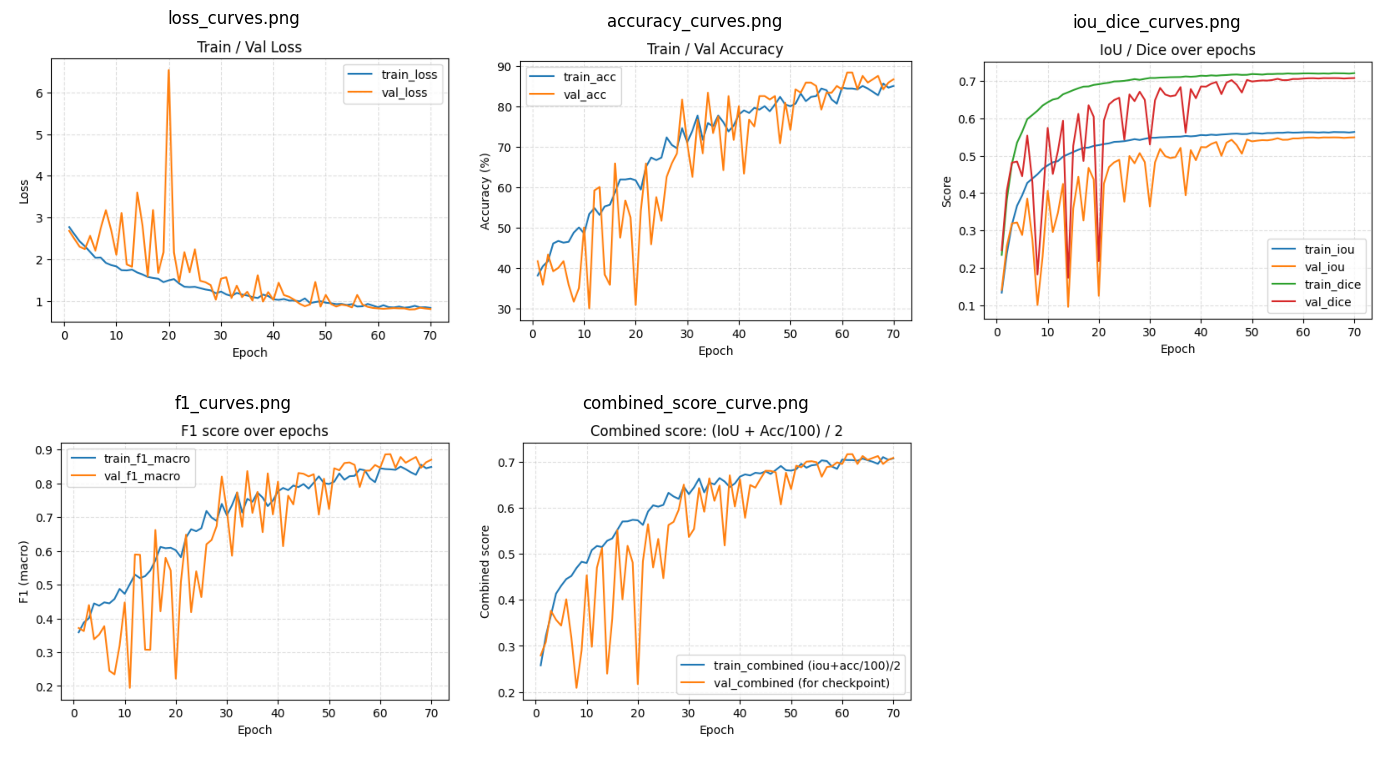

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

curve_names = [
    "loss_curves.png",
    "accuracy_curves.png",
    "iou_dice_curves.png",
    "f1_curves.png",
    "combined_score_curve.png",
]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for ax, name in zip(axes, curve_names):
    p = os.path.join(OUTPUT_DIR, name)
    if os.path.isfile(p):
        ax.imshow(Image.open(p))
        ax.set_title(name)
    ax.axis("off")

if len(curve_names) < len(axes):
    axes[len(curve_names)].axis("off")
plt.tight_layout()
plt.show()

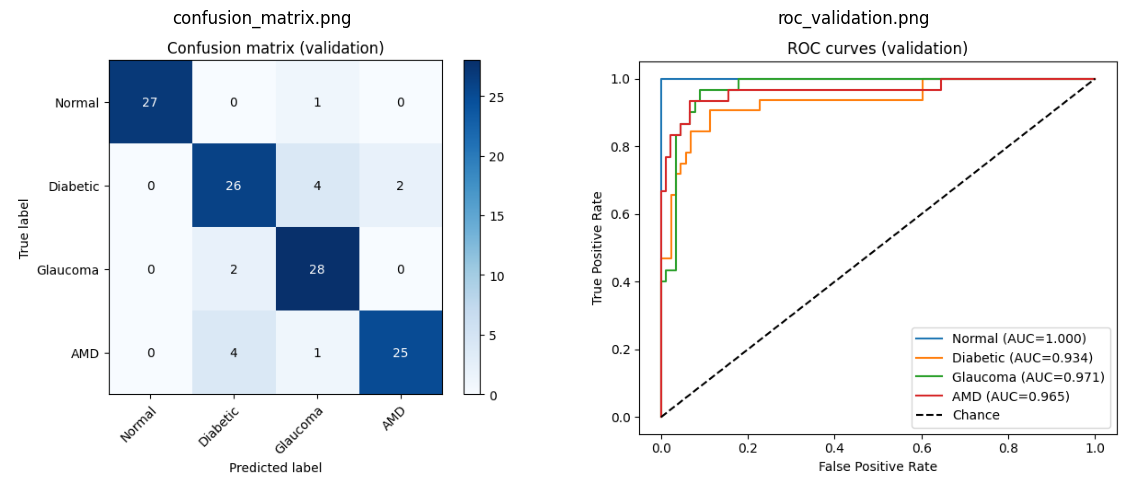

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name in zip(axes, ["confusion_matrix.png", "roc_validation.png"]):
    p = os.path.join(OUTPUT_DIR, name)
    if os.path.isfile(p):
        ax.imshow(Image.open(p))
        ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

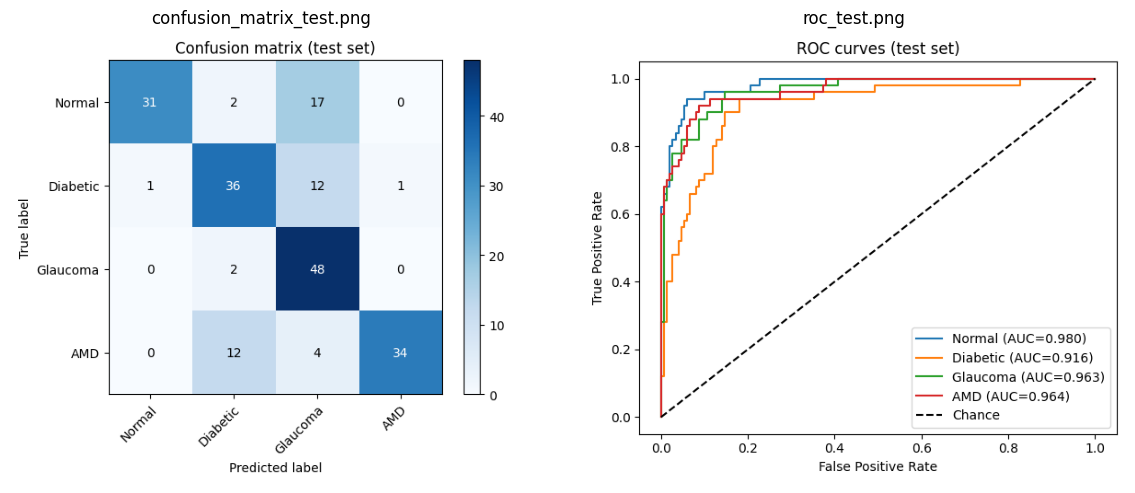

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name in zip(axes, ["confusion_matrix_test.png", "roc_test.png"]):
    p = os.path.join(OUTPUT_DIR, name)
    if os.path.isfile(p):
        ax.imshow(Image.open(p))
        ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()